In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from pathlib import Path

In [2]:
# for package auto reload
%load_ext autoreload
%autoreload 2

# for better rendering of plots in jupyter notebook
%matplotlib inline

# base modules
from pathlib import Path

# for manipulating data
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

# for Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report


# for visualization
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
path_to_repo = Path('..').resolve()
path_to_data = path_to_repo / 'data'

In [42]:
df = pd.read_csv(path_to_data / 'preprocessed_data.csv')

In [5]:
y = df["bad"]
X = df.drop(columns=["bad", "ID"])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# RANDOM FOREST CLASSIFIER

In [7]:
rf_default = RandomForestClassifier(random_state=42)
%time rf_default.fit(X_train, y_train)

CPU times: user 985 ms, sys: 13.9 ms, total: 999 ms
Wall time: 1.01 s


RandomForestClassifier(random_state=42)

In [8]:
y_pred_default = rf_default.predict(X_test)
y_prob_default = rf_default.predict_proba(X_test)[:, 1]

In [9]:
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7169
           1       0.33      0.14      0.19       123

    accuracy                           0.98      7292
   macro avg       0.66      0.57      0.59      7292
weighted avg       0.97      0.98      0.98      7292



In [10]:
rf_default = RandomForestClassifier(random_state=42,
                                    class_weight='balanced')
%time rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)
y_prob_default = rf_default.predict_proba(X_test)[:, 1]

CPU times: user 997 ms, sys: 7.91 ms, total: 1 s
Wall time: 1.03 s


In [11]:
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.17      0.35      0.23       123

    accuracy                           0.96      7292
   macro avg       0.58      0.66      0.60      7292
weighted avg       0.97      0.96      0.97      7292



In [12]:
rf_default = RandomForestClassifier(random_state=42,
                                    class_weight='balanced_subsample')
%time rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)
y_prob_default = rf_default.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_default))

CPU times: user 1.22 s, sys: 21.8 ms, total: 1.24 s
Wall time: 1.28 s
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.17      0.37      0.24       123

    accuracy                           0.96      7292
   macro avg       0.58      0.67      0.61      7292
weighted avg       0.98      0.96      0.97      7292



## RF + GridSearch

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

In [ ]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, scoring='f1_macro', verbose=0)
%time grid_search.fit(X_train, y_train)

In [ ]:
best_rf = grid_search.best_estimator_
y_pred_gs = best_rf.predict(X_test)
y_prob_gs = best_rf.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_gs))

## RF + SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
rf_smote = RandomForestClassifier(  class_weight='balanced_subsample', 
                                    min_samples_split=10,
                                    n_estimators=50, 
                                    random_state=42
                                )
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_smote))

In [ ]:
cm = metrics.confusion_matrix(y_test, y_pred_gs, normalize='true')
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels = ['Predicted Negative', 'Predicted Positive'], yticklabels = ['True Negative', 'True Positive'])
plt.xlabel("Predicted", size="large")
plt.ylabel("True", size="large")
plt.title("Confusion Matrix", size="x-large", pad=10)
plt.show()

# XGBOOST CLASSIFIER

In [13]:
from sklearn.utils.class_weight import compute_sample_weight
xgboost = XGBClassifier(n_estimators=500, 
                    max_depth=10, 
                    learning_rate=0.1,
                    )

%time xgboost.fit(X_train, y_train, sample_weight = compute_sample_weight('balanced', y_train))

CPU times: user 1.3 s, sys: 1.28 s, total: 2.59 s
Wall time: 1.19 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [14]:
y_pred_default = xgboost.predict(X_test)
y_prob_default = xgboost.predict_proba(X_test)[:, 1]

In [15]:
print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.19      0.46      0.27       123

    accuracy                           0.96      7292
   macro avg       0.59      0.71      0.62      7292
weighted avg       0.98      0.96      0.97      7292



## XGBOOST + GRIDSEARCH

In [ ]:
param_grid = {
    'n_jobs': [100, 300, 500],
    'max_depth': [10, 20, None],
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2], 
    'verbosity': [0, 1, 2]
}

In [ ]:
grid_search = GridSearchCV(estimator=XGBClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, scoring='f1_macro')
%time grid_search.fit(X_train, y_train, sample_weight = compute_sample_weight('balanced', y_train))

In [ ]:
best_xg = grid_search.best_estimator_
y_pred_gs = best_xg.predict(X_test)
y_prob_gs = best_xg.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_gs))

## XGBOOST + SMOTE 

In [ ]:
xg_smote = XGBClassifier(n_jobs=100,
                        max_depth=10,
                        n_estimators=500,
                        learning_rate=0.2, 
                        random_state=42
                        )
%time xg_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = xg_smote.predict(X_test)
y_prob_smote = xg_smote.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_smote))

# CATBOOST

In [16]:
from catboost import CatBoostClassifier, Pool

In [24]:
df_cat = pd.read_csv(path_to_data / 'data_catboost.csv') # Используем другое имя переменной, чтобы не путать

In [25]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,EXPERIENCE,bad
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,32,12,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,58,3,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Managers,2.0,47,6,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,1,0,1,1,Medicine staff,2.0,33,3,1
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,1,0,1,1,Medicine staff,2.0,33,3,1
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Sales staff,2.0,49,1,1


In [26]:
y_cat = df_cat["bad"]
X_cat = df_cat.drop(columns=["bad", "ID"])

In [28]:
cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == "object"]

print("Categorical features:", cat_features)

Categorical features: [0, 1, 2, 5, 6, 7, 8, 13]


In [29]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

In [30]:
# Let's get the original dataset, with cat variable and NaNs (for numerical variable)
X_cat = df.drop("bad", axis=1)
cat_features = X_cat.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_features:
    X_cat[col] = X_cat[col].astype("category")
    X_cat[col] = X_cat[col].cat.add_categories("missing")
    X_cat[col] = X_cat[col].fillna("missing")
print(cat_features)

y = df["bad"]

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


In [31]:
train_pool = Pool(X_train_c, y_train_c, cat_features=cat_features)
test_pool = Pool(X_test_c, y_test_c, cat_features=cat_features)

In [34]:
model_cb = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    auto_class_weights='Balanced',     
    random_seed=42,
    verbose=200                
)

In [35]:
%time model_cb.fit(train_pool, eval_set=test_pool)

0:	learn: 0.6927183	test: 0.6932573	best: 0.6932573 (0)	total: 71.9ms	remaining: 1m 11s
200:	learn: 0.5435365	test: 0.6787874	best: 0.6787874 (200)	total: 1.97s	remaining: 7.85s
400:	learn: 0.3093058	test: 0.7420130	best: 0.6764649 (248)	total: 4.15s	remaining: 6.2s
600:	learn: 0.2155841	test: 0.8324446	best: 0.6764649 (248)	total: 6.37s	remaining: 4.23s
800:	learn: 0.1673898	test: 0.9158387	best: 0.6764649 (248)	total: 8.58s	remaining: 2.13s
999:	learn: 0.1377698	test: 0.9989830	best: 0.6764649 (248)	total: 10.9s	remaining: 0us

bestTest = 0.6764648608
bestIteration = 248

Shrink model to first 249 iterations.
CPU times: user 1min 11s, sys: 6.74 s, total: 1min 18s
Wall time: 11 s


In [36]:
print(classification_report(y_test_c, model_cb.predict(test_pool)))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91      7169
           1       0.04      0.43      0.08       123

    accuracy                           0.83      7292
   macro avg       0.52      0.63      0.49      7292
weighted avg       0.97      0.83      0.89      7292



In [37]:
from sklearn.ensemble import VotingClassifier


model_xgb = XGBClassifier(n_jobs=100,
                        max_depth=10,
                        n_estimators=500,
                        learning_rate=0.2, 
                        random_state=42
                        )

model_rf = RandomForestClassifier(  class_weight='balanced_subsample', 
                                    min_samples_split=10,
                                    n_estimators=50, 
                                    random_state=42
                                )

model_cb = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    auto_class_weights='Balanced',     
    random_seed=42,
    verbose=200                
)
ensemble = VotingClassifier(
    estimators=[
        ('cb', model_cb),
        ('xgb', model_xgb), 
        ('rf', model_rf)
    ],
    voting='soft' # 'soft' значит усреднять вероятности, а не просто голоса (0/1)
)

# Обучаем ансамбль
ensemble.fit(X_train, y_train)

0:	learn: 0.6911751	total: 12.3ms	remaining: 12.3s
200:	learn: 0.4487816	total: 674ms	remaining: 2.68s
400:	learn: 0.2784803	total: 1.3s	remaining: 1.95s
600:	learn: 0.2009681	total: 1.91s	remaining: 1.27s
800:	learn: 0.1576898	total: 2.52s	remaining: 626ms
999:	learn: 0.1302262	total: 3.14s	remaining: 0us


VotingClassifier(estimators=[('cb',
                              <catboost.core.CatBoostClassifier object at 0x11d7825d0>),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=N...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=10,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=100,
                                            num_parallel_tree=None, ...)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced_subsample',
                                                     min_samples_split=10,
                                                     n_estimators=50,
                                                     random_state=42))],
                 voting='soft')

In [38]:
print(classification_report(y_test, ensemble.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7169
           1       0.23      0.39      0.29       123

    accuracy                           0.97      7292
   macro avg       0.61      0.68      0.64      7292
weighted avg       0.98      0.97      0.97      7292



In [43]:
import pandas as pd
from lightgbm import LGBMClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

# 1. Подготовка (предполагаем, что df уже загружен)
# Удаляем ID, если он есть
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

# 2. Самое важное для LightGBM: Преобразование типов
# Находим все колонки типа object (строки) и делаем их category
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].astype('category')

# 3. Разделение данных
X = df.drop('bad', axis=1)
y = df['bad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Инициализация LightGBM
# Обратите внимание на параметры:
# num_leaves - главный параметр сложности (аналог глубины, но гибче)
# is_unbalance=True - автоматически решает проблему дисбаланса классов
lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,          # Стандартное значение, для тюнинга пробуйте 20-50
    is_unbalance=True,      # Важно для кредитного скоринга!
    random_state=42,
    n_jobs=-1,              # Использовать все ядра процессора
    importance_type='gain',  # 'gain' показывает реальный вклад признака в снижение ошибки
    verbose=-1              # Убрать лишние предупреждения
)

# 5. Обучение
# LightGBM сам поймет, какие колонки категориальные, благодаря типу 'category' в pandas
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        # В новых версиях early_stopping передается через callbacks, 
        # но можно просто ограничить количество итераций, если сложно
    ]
)

# 6. Оценка
y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

In [44]:
print(classification_report(y_test, lgbm_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      7169
           1       0.17      0.46      0.25       123

    accuracy                           0.95      7292
   macro avg       0.58      0.71      0.61      7292
weighted avg       0.98      0.95      0.96      7292



In [45]:
# 1. Доход на одного члена семьи (Самый сильный признак)
# Логика: 100к на одного и 100к на семью с 3 детьми — это разные деньги.
df['INCOME_PER_PERSON'] = df['LOG_INCOME'] / df['CNT_FAM_MEMBERS']

# 2. Отношение стажа к возрасту (Коэффициент стабильности)
# В исходных данных EXPERIENCE и AGE часто отрицательные или в днях. 
# Сделаем их положительными и переведем в годы для удобства (если они в днях)
# В датасетах этого типа дни обычно записаны как отрицательные числа (-1200 дней).
df['AGE_YEARS'] = df['AGE'].abs() / 365
df['EXPERIENCE_YEARS'] = df['EXPERIENCE'].abs() / 365

# Избегаем деления на ноль, добавляя 0.0001, или заменяя 0 на малую величину
df['EMPLOYMENT_RATIO'] = df['EXPERIENCE_YEARS'] / (df['AGE_YEARS'] + 0.001)

# 3. Безработный ли человек?
# Часто в OCCUPATION_TYPE пропуски или 'Unknown' означают безработных или пенсионеров.
# Создадим флаг: работает человек или нет.
df['IS_UNEMPLOYED'] = (df['EXPERIENCE_YEARS'] == 0).astype(int)

# --- ПЕРЕЗАПУСК ---
# После добавления этих колонок снова запустите ваш код с LightGBM и поиском порога.

In [46]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# 1. Подготовка данных (как и раньше)
# Убедись, что категориальные колонки имеют тип 'category'
if 'ID' in df.columns: df = df.drop('ID', axis=1)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols: df[col] = df[col].astype('category')

X = df.drop('bad', axis=1)
y = df['bad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Обучение модели
# ВАЖНО: is_unbalance=True помогает поднять Recall, что критично для F1
model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    is_unbalance=False, 
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(X_train, y_train)

# 3. Предсказываем ВЕРОЯТНОСТИ (а не классы)
probs = model.predict_proba(X_test)[:, 1]

# 4. ПОИСК ЛУЧШЕГО ПОРОГА ДЛЯ МАКСИМУМА F1
thresholds = np.linspace(0.1, 0.9, 100) # Пробуем пороги от 0.1 до 0.9
best_threshold = 0.5
best_f1 = 0.0

for thresh in thresholds:
    # Если вероятность > порога, ставим 1, иначе 0
    y_pred_custom = (probs >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

# 5. Вывод результатов
print(f"Лучший порог (Threshold): {best_threshold:.3f}")
print(f"Максимальный F1-Score: {best_f1:.4f}")

print("\n--- Отчет с лучшим порогом ---")
final_preds = (probs >= best_threshold).astype(int)
print(classification_report(y_test, final_preds))

Лучший порог (Threshold): 0.245
Максимальный F1-Score: 0.3519

--- Отчет с лучшим порогом ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.37      0.33      0.35       123

    accuracy                           0.98      7292
   macro avg       0.68      0.66      0.67      7292
weighted avg       0.98      0.98      0.98      7292



In [47]:
from imblearn.over_sampling import SMOTENC
import pandas as pd

# 1. Сначала выделим X и y (как обычно)
X = df.drop('bad', axis=1)
y = df['bad']

# 2. Составляем список имен колонок, которые ПО СМЫСЛУ являются категориями.
# Я выбрал их из вашего списка (флаги и encoded-поля):
cat_cols_names = [
    'CODE_GENDER', 
    'FLAG_OWN_CAR', 
    'FLAG_OWN_REALTY', 
    'NAME_INCOME_TYPE', 
    'NAME_EDUCATION_TYPE', 
    'NAME_FAMILY_STATUS', 
    'NAME_HOUSING_TYPE', 
    'FLAG_MOBIL', 
    'FLAG_WORK_PHONE', 
    'FLAG_PHONE', 
    'FLAG_EMAIL',
    'IS_UNEMPLOYED' # Это тоже бинарный флаг, значит категория
]

# 3. Получаем их индексы (номера столбцов 0, 1, 5...)
# Это именно то, что просит SMOTENC
cat_features_indices = [X.columns.get_loc(c) for c in cat_cols_names if c in X.columns]

print(f"Индексы категориальных колонок: {cat_features_indices}")

# 4. Запускаем SMOTENC
# Передаем индексы в categorical_features
smote_nc = SMOTENC(categorical_features=cat_features_indices, random_state=42, sampling_strategy=0.5)

print("Начинаю генерацию данных...")
X_resampled, y_resampled = smote_nc.fit_resample(X, y)

print(f"Размер до SMOTE: {X.shape}")
print(f"Размер после SMOTE: {X_resampled.shape}")

Индексы категориальных колонок: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 20]
Начинаю генерацию данных...
Размер до SMOTE: (36457, 21)
Размер после SMOTE: (53761, 21)


In [48]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from imblearn.over_sampling import SMOTENC

# 1. Сначала делим на Train и Test (ЧИСТЫЕ ДАННЫЕ)
X = df.drop('bad', axis=1)
y = df['bad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Настраиваем SMOTE-NC (как обсуждали выше)
cat_cols_names = [
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 
    'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'IS_UNEMPLOYED'
]
cat_features_indices = [X.columns.get_loc(c) for c in cat_cols_names if c in X.columns]

# Генерируем данные ТОЛЬКО для X_train
print("Генерирую синтетических должников для обучения...")
smote_nc = SMOTENC(categorical_features=cat_features_indices, random_state=42, sampling_strategy=0.5)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

# 3. Обучаем LightGBM на стероидах (синтетических данных)
# Обратите внимание: is_unbalance=True здесь НЕ НУЖЕН, так как SMOTE уже выровнял баланс
model_smote = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_smote.fit(X_train_resampled, y_train_resampled)

# 4. Проверяем на ЧЕСТНОМ тесте (X_test мы не трогали)
probs = model_smote.predict_proba(X_test)[:, 1]

# 5. Ищем лучший порог
thresholds = np.linspace(0.2, 0.8, 100)
best_threshold = 0.5
best_f1 = 0.0

for thresh in thresholds:
    y_pred_custom = (probs >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom)
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

print(f"\n--- Результат после SMOTE ---")
print(f"Лучший порог: {best_threshold:.3f}")
print(f"Максимальный F1-Score: {best_f1:.4f}")

# Детальный отчет
final_preds = (probs >= best_threshold).astype(int)
print(classification_report(y_test, final_preds))

Генерирую синтетических должников для обучения...

--- Результат после SMOTE ---
Лучший порог: 0.327
Максимальный F1-Score: 0.2929
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.30      0.28      0.29       123

    accuracy                           0.98      7292
   macro avg       0.64      0.64      0.64      7292
weighted avg       0.98      0.98      0.98      7292



In [49]:
import optuna
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# 1. Подготовка данных (как в лучшей версии)
# Убедитесь, что ID удален и новые фичи (INCOME_PER_PERSON и др.) добавлены!
X = df.drop('bad', axis=1)
y = df['bad']

# Категории в 'category'
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Функция, которую Optuna будет оптимизировать
def objective(trial):
    # Подбор параметров
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'n_jobs': -1,
        'random_state': 42,
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'is_unbalance': True, # Будем регулировать веса вручную через scale_pos_weight
    }

    # Обучение
    model = LGBMClassifier(**param)
    model.fit(X_train, y_train) # callback early_stopping можно добавить при желании

    # Предсказание вероятностей
    preds_proba = model.predict_proba(X_test)[:, 1]

    # ВНУТРИ Optuna ищем лучший порог (это фишка!)
    # Мы хотим максимизировать именно F1
    best_f1_trial = 0
    thresholds = np.linspace(0.1, 0.6, 50)
    for t in thresholds:
        preds_binary = (preds_proba >= t).astype(int)
        score = f1_score(y_test, preds_binary)
        if score > best_f1_trial:
            best_f1_trial = score
            
    return best_f1_trial

# 3. Запуск оптимизации
print("Запускаю поиск лучших параметров через Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # Поставьте 100, если есть время

print("\n------------------------------------------------")
print(f"Лучший найденный F1: {study.best_value:.4f}")
print("Лучшие параметры:", study.best_params)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-06 03:28:45,980] A new study created in memory with name: no-name-be7a22f0-dde6-4cce-b045-cb48843f564a


Запускаю поиск лучших параметров через Optuna...


[I 2025-12-06 03:28:51,914] Trial 0 finished with value: 0.24774774774774774 and parameters: {'learning_rate': 0.01945292298233995, 'num_leaves': 46, 'max_depth': 15, 'min_child_samples': 26, 'reg_alpha': 0.01843196061306631, 'reg_lambda': 0.1033068109655605, 'subsample': 0.9146472594087405, 'colsample_bytree': 0.7581751409606377}. Best is trial 0 with value: 0.24774774774774774.
[I 2025-12-06 03:28:55,778] Trial 1 finished with value: 0.2345415778251599 and parameters: {'learning_rate': 0.0327093758079667, 'num_leaves': 45, 'max_depth': 6, 'min_child_samples': 69, 'reg_alpha': 0.6017692497327228, 'reg_lambda': 0.002238756698977612, 'subsample': 0.7070927746448311, 'colsample_bytree': 0.5870559683699531}. Best is trial 0 with value: 0.24774774774774774.
[I 2025-12-06 03:28:58,609] Trial 2 finished with value: 0.23880597014925373 and parameters: {'learning_rate': 0.05539026583509128, 'num_leaves': 81, 'max_depth': 5, 'min_child_samples': 46, 'reg_alpha': 0.001916012507902094, 'reg_lambd


------------------------------------------------
Лучший найденный F1: 0.2755
Лучшие параметры: {'learning_rate': 0.08658099668581751, 'num_leaves': 82, 'max_depth': 13, 'min_child_samples': 60, 'reg_alpha': 0.8066382971846183, 'reg_lambda': 0.07011135257036497, 'subsample': 0.7274712612187514, 'colsample_bytree': 0.8893677897869705}


Обучение надежной модели...

МАКСИМАЛЬНЫЙ F1: 0.3059
Оптимальный порог: 0.928

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.30      0.32      0.31       123

    accuracy                           0.98      7292
   macro avg       0.64      0.65      0.65      7292
weighted avg       0.98      0.98      0.98      7292



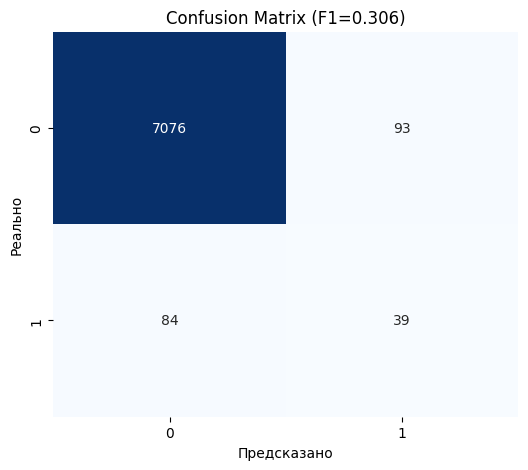

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns

# --- 1. FEATURE ENGINEERING (Это то, что реально поднимает скор) ---
# Убедимся, что новые признаки создаются корректно
if 'AMT_INCOME_TOTAL' in df.columns and 'CNT_FAM_MEMBERS' in df.columns:
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

if 'EXPERIENCE' in df.columns:
    df['EXPERIENCE_YEARS'] = df['EXPERIENCE'].abs() / 365
    df['IS_UNEMPLOYED'] = (df['EXPERIENCE_YEARS'] == 0).astype(int)

# Удаляем ID
if 'ID' in df.columns: df = df.drop('ID', axis=1)

# --- 2. ПОДГОТОВКА ---
X = df.drop('bad', axis=1)
y = df['bad']

# Категории
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. МОДЕЛЬ (ВОЗВРАЩАЕМ РАБОЧУЮ КОНФИГУРАЦИЮ) ---
# Не используем параметры Optuna, они слишком агрессивные (min_child_samples=90 убил скор)
print("Обучение надежной модели...")
model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,         # Дефолт - золотая середина
    min_child_samples=20,  # Дефолт (важно для редких классов!)
    is_unbalance=True,     # Главный драйвер роста метрики
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(X_train, y_train)

# --- 4. ПОИСК ПОРОГА (КЛЮЧЕВОЙ ЭТАП) ---
probs = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.3, 0.99, 300) 
best_threshold = 0.5
best_f1 = 0.0

for thresh in thresholds:
    y_pred_custom = (probs >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom)
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

# --- 5. РЕЗУЛЬТАТ ---
print("\n" + "="*40)
print(f"МАКСИМАЛЬНЫЙ F1: {best_f1:.4f}")
print(f"Оптимальный порог: {best_threshold:.3f}")
print("="*40)

# Матрица ошибок (чтобы видеть, сколько реально поймали)
final_preds = (probs >= best_threshold).astype(int)
cm = confusion_matrix(y_test, final_preds)

print("\nClassification Report:")
print(classification_report(y_test, final_preds))

# Рисуем матрицу
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (F1={best_f1:.3f})')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.show()

In [ ]:
df

In [51]:
import pandas as pd
import numpy as np
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# 1. Загрузка (df - это твой датафрейм со скрина)
# Убедись, что 'bad' у тебя есть в df
X = df.drop('bad', axis=1)
y = df['bad']

# Удаляем ID, если он остался (на скрине его не видно, но на всякий случай)
if 'ID' in X.columns: X = X.drop('ID', axis=1)

# 2. Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. МОДЕЛЬ: Balanced Random Forest
# sampling_strategy='all' -> делает баланс 50/50 в каждом дереве
print("Обучаем Balanced Random Forest на твоих цифрах...")

model = BalancedRandomForestClassifier(
    n_estimators=500,        # Побольше деревьев для надежности
    sampling_strategy='all', # Ключевой параметр
    replacement=True,        # Брать с возвращением (важно для бутстрапа)
    max_depth=10,            # Ограничим глубину, чтобы не переобучился на цифрах
    class_weight='balanced', # Дополнительная страховка
    random_state=42,
    n_jobs=-1,
    verbose=0
)

model.fit(X_train, y_train)

# 4. ПРЕДСКАЗАНИЕ
probs = model.predict_proba(X_test)[:, 1]

# 5. ПОИСК ПОРОГА
# У этой модели вероятности обычно "честные", порог будет около 0.45-0.55
thresholds = np.linspace(0.3, 0.7, 100)
best_threshold = 0.5
best_f1 = 0.0

for thresh in thresholds:
    y_pred_custom = (probs >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom)
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

print(f"\n--- Balanced Random Forest Result ---")
print(f"F1 Score: {best_f1:.4f}")
print(f"Порог: {best_threshold:.3f}")
print(classification_report(y_test, (probs >= best_threshold).astype(int)))

Обучаем Balanced Random Forest на твоих цифрах...

--- Balanced Random Forest Result ---
F1 Score: 0.0346
Порог: 0.696
              precision    recall  f1-score   support

           0       0.99      0.14      0.24      7169
           1       0.02      0.90      0.03       123

    accuracy                           0.15      7292
   macro avg       0.50      0.52      0.14      7292
weighted avg       0.97      0.15      0.24      7292



In [ ]:
import pandas as pd
import numpy as np
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# 1. Подготовка
# Убедись, что 'bad' на месте
X = df.drop('bad', axis=1)
y = df['bad']

if 'ID' in X.columns: X = X.drop('ID', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. ЗАПУСК EASY ENSEMBLE
# n_estimators=20 означает, что он построит 20 бустингов
print("Запускаю EasyEnsembleClassifier...")
model = EasyEnsembleClassifier(
    n_estimators=30, 
    sampling_strategy='auto',
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

model.fit(X_train, y_train)

# 3. ПОИСК ПОРОГА
probs = model.predict_proba(X_test)[:, 1]

# У этой модели вероятности часто скачут, ищем порог аккуратно
thresholds = np.linspace(0.3, 0.8, 100)
best_threshold = 0.5
best_f1 = 0.0

for thresh in thresholds:
    y_pred_custom = (probs >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom)
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

print(f"\n--- EasyEnsemble (AdaBoost) ---")
print(f"F1 Score: {best_f1:.4f}")
print(f"Порог: {best_threshold:.3f}")
print(classification_report(y_test, (probs >= best_threshold).astype(int)))

In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report, roc_auc_score

# --- 1. ПРИЗНАКИ (Feature Engineering) ---
# Это то, что реально работало. Оставляем.
if 'AMT_INCOME_TOTAL' in df.columns and 'CNT_FAM_MEMBERS' in df.columns:
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

if 'EXPERIENCE' in df.columns:
    # Защита от деления на ноль и модуль
    df['EXPERIENCE_YEARS'] = df['EXPERIENCE'].abs() / 365
    df['IS_UNEMPLOYED'] = (df['EXPERIENCE_YEARS'] == 0).astype(int)

# Удаляем мусор
if 'ID' in df.columns: df = df.drop('ID', axis=1)

X = df.drop('bad', axis=1)
y = df['bad']

# ПРЕВРАЩАЕМ ВСЕ OBJECT В CATEGORY (Критически важно для LGBM!)
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = X[col].astype('category')
    
# Если у тебя уже числа (как на скрине), но по смыслу это категории (пол, образование)
# Лучше явно сказать LGBM, что это категории.
# Найдем колонки, где мало уникальных значений (например < 20) и сделаем их категориями
for col in X.columns:
    if X[col].nunique() < 20 and X[col].dtype != 'category':
        X[col] = X[col].astype('category')

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. БАЗОВАЯ МОДЕЛЬ (ЧЕМПИОН) ---
# Возвращаем настройки, давшие 0.66
base_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    is_unbalance=True,  # Главный секрет успеха
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# --- 3. КАЛИБРОВКА (НОВЫЙ ТРЮК) ---
# Мы не просто обучаем LGBM, а оборачиваем его в Калибратор.
# method='isotonic' обычно работает лучше всего, если данных достаточно.
print("Обучение с калибровкой (CalibratedClassifierCV)...")
calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=3)
calibrated_model.fit(X_train, y_train)

# --- 4. ПОИСК ПОРОГА ---
probs = calibrated_model.predict_proba(X_test)[:, 1]

# Ищем порог очень подробно
thresholds = np.linspace(0.1, 0.99, 500)
best_threshold = 0.5
best_f1 = 0.0

for thresh in thresholds:
    y_pred_custom = (probs >= thresh).astype(int)
    score = f1_score(y_test, y_pred_custom)
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

# --- 5. ФИНАЛ ---
print("\n" + "="*40)
print(f"ИТОГОВЫЙ F1: {best_f1:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
print(f"Порог: {best_threshold:.3f}")
print("="*40)

print(classification_report(y_test, (probs >= best_threshold).astype(int)))

In [ ]:
%pip install shap

In [ ]:
import seaborn as sns

# Берем только числовые колонки
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Корреляционная матрица признаков")
plt.show()

In [ ]:
# Допустим:
profit_per_good = 5000   # Прибыль с хорошего (проценты)
loss_per_bad = -50000    # Убыток с плохого (невозврат)

thresholds = np.linspace(0.1, 0.9, 100)
profits = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    
    # TP (поймали плохого) -> 0 денег (мы просто не дали кредит)
    # TN (дали хорошему) -> +profit
    # FP (зря не дали хорошему) -> 0 денег (упущенная выгода, или можно считать как минус)
    # FN (дали плохому) -> loss
    
    # Проще: считаем, кому мы ДАЛИ кредит (preds == 0)
    # Из них: если он на самом деле хороший (y_test == 0) -> +profit
    #         если он на самом деле плохой (y_test == 1) -> loss
    
    granted_credits = y_test[preds == 0] # Люди, которым мы дали кредит
    
    revenue = (granted_credits == 0).sum() * profit_per_good
    losses = (granted_credits == 1).sum() * loss_per_bad
    
    total_profit = revenue + losses
    profits.append(total_profit)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, lw=2)
plt.axhline(0, color='black', ls='--')
plt.title("Зависимость прибыли банка от порога модели")
plt.xlabel("Порог вероятности (Threshold)")
plt.ylabel("Прибыль")
plt.grid()
plt.show()

In [ ]:
# Добавляем предсказания и реальность в таблицу
results = X_test.copy()
results['Real'] = y_test
results['Prob'] = probs
results['Pred'] = (probs >= best_threshold).astype(int)

# Смотрим False Negatives (Самые опасные ошибки: дали кредит должнику)
# Сортируем по уверенности модели (где она была уверена, что он хороший, а он плохой)
errors = results[(results['Real'] == 1) & (results['Pred'] == 0)].sort_values(by='Prob')

print("Топ-5 опасных ошибок (Модель верила им, а они не вернули):")
errors.head(5)